In [1]:
import os
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print("Libraries loaded.")

Libraries loaded.


In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# **DATA LOADER**

In [3]:
PROCESSED_DATA_DIR = Path('../../data/processed_garbage')
IMAGE_SIZE         = (128, 128)

TRAIN_DIR = PROCESSED_DATA_DIR / 'train'
VAL_DIR   = PROCESSED_DATA_DIR / 'val'
TEST_DIR  = PROCESSED_DATA_DIR / 'test'

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")

for split_name in ['train', 'val', 'test']:
    total = sum(
        len(list((PROCESSED_DATA_DIR / split_name / cls).glob('*')))
        for cls in CLASS_NAMES
        if (PROCESSED_DATA_DIR / split_name / cls).exists()
    )
    print(f"Total {split_name:5}: {total} gambar")

Kelas (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Total train: 10866 gambar
Total val  : 2333 gambar
Total test : 2352 gambar


# **FEATURE EXTRACTION**

Pipeline ekstraksi fitur per gambar:
1. Resize ke 128x128
2. CLAHE (Contrast Limited Adaptive Histogram Equalization) — perjelas tepi untuk HOG
3. **HOG** (Histogram of Oriented Gradients) — tangkap bentuk & tepi
4. **Color Histogram** (HSV, 32 bins/channel) — tangkap distribusi warna
5. Concatenate HOG + Color Hist — satu vektor fitur per gambar

In [4]:
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
COLOR_HIST_BINS     = 32


def apply_clahe(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_img)


def extract_hog_features(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = apply_clahe(gray)
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True,
    )
    return features


def extract_color_hist(img_rgb):
    img_hsv    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    ranges     = [(0, 180), (0, 256), (0, 256)]
    hist_parts = []
    for ch, (lo, hi) in enumerate(ranges):
        hist = cv2.calcHist([img_hsv], [ch], None, [COLOR_HIST_BINS], [lo, hi])
        hist = cv2.normalize(hist, hist).flatten()
        hist_parts.append(hist)
    return np.concatenate(hist_parts)


def extract_features_from_image(img_path):
    img    = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    img_np = np.array(img, dtype=np.uint8)
    return np.concatenate([extract_hog_features(img_np), extract_color_hist(img_np)])


def load_split(split_dir):
    features, labels = [], []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        img_paths = [
            p for p in class_dir.glob('*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ]
        for img_path in img_paths:
            try:
                features.append(extract_features_from_image(img_path))
                labels.append(label_idx)
            except Exception:
                pass
        print(f"  {class_name:15}: {len(img_paths)} gambar")
    return np.array(features), np.array(labels)


sample_img_path = next((TRAIN_DIR / CLASS_NAMES[0]).glob('*'))
sample_feat     = extract_features_from_image(sample_img_path)
print(f"Dimensi fitur per gambar : {sample_feat.shape[0]}")

Dimensi fitur per gambar : 8196


In [5]:
CHECKPOINT_DIR = Path('../../model/checkpoints_svm_hog_colorhist')
FEATURES_PATH  = CHECKPOINT_DIR / 'features.npz'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if FEATURES_PATH.exists():
    print(f"Features found at {FEATURES_PATH}, loading...")
    data    = np.load(FEATURES_PATH)
    X_train = data['X_train']; y_train = data['y_train']
    X_val   = data['X_val'];   y_val   = data['y_val']
    X_test  = data['X_test'];  y_test  = data['y_test']
    print("Features loaded.")
else:
    print("Extracting train features...")
    X_train, y_train = load_split(TRAIN_DIR)

    print("\nExtracting val features...")
    X_val, y_val = load_split(VAL_DIR)

    print("\nExtracting test features...")
    X_test, y_test = load_split(TEST_DIR)

    np.savez_compressed(
        FEATURES_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        X_test=X_test,   y_test=y_test,
    )
    print(f"\nFeatures saved to {FEATURES_PATH}")

print(f"\nX_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")

Features found at ../../model/checkpoints_svm_hog_colorhist/features.npz, loading...
Features loaded.

X_train shape : (10854, 8196)
X_val   shape : (2321, 8196)
X_test  shape : (2340, 8196)


# **MODELING (SVM)**

In [6]:
SVM_MODEL_PATH = CHECKPOINT_DIR / 'svm_model.pkl'

if SVM_MODEL_PATH.exists():
    print(f"SVM model found, loading from {SVM_MODEL_PATH}")
    with open(SVM_MODEL_PATH, 'rb') as f:
        pipeline = pickle.load(f)
    print("SVM model loaded.")
else:
    print("Training SVM (RBF kernel, C=10, gamma=scale) + StandardScaler...")
    print("This may take several minutes.")

    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            decision_function_shape='ovr',
            probability=True,
            random_state=RANDOM_SEED,
            verbose=True,
        )),
    ])
    pipeline.fit(X_trainval, y_trainval)

    with open(SVM_MODEL_PATH, 'wb') as f:
        pickle.dump(pipeline, f)
    print(f"SVM model saved to {SVM_MODEL_PATH}")

Training SVM (RBF kernel, C=10, gamma=scale) + StandardScaler...
This may take several minutes.
[LibSVM].*
optimization finished, #iter = 1450
obj = -272.417515, rho = 0.673448
nSV = 847, nBSV = 0
Total nSV = 847
.*
optimization finished, #iter = 1474
obj = -268.592522, rho = 0.674937
nSV = 851, nBSV = 0
Total nSV = 851
.*
optimization finished, #iter = 1465
obj = -272.534362, rho = 0.679026
nSV = 864, nBSV = 0
Total nSV = 864
.*
optimization finished, #iter = 1442
obj = -265.519299, rho = 0.640511
nSV = 848, nBSV = 0
Total nSV = 848
.*
optimization finished, #iter = 1457
obj = -273.002854, rho = 0.758841
nSV = 849, nBSV = 0
Total nSV = 849
.*
optimization finished, #iter = 1793
obj = -325.367943, rho = -0.668192
nSV = 1035, nBSV = 0
.*
optimization finished, #iter = 1555
obj = -349.553716, rho = 0.174536
nSV = 867, nBSV = 0
Total nSV = 867
.*
optimization finished, #iter = 1516
obj = -344.133106, rho = 0.205484
nSV = 856, nBSV = 0
Total nSV = 856
.*
optimization finished, #iter = 1555

# **EVALUATION**

In [7]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

train_preds = pipeline.predict(X_trainval)
train_acc   = accuracy_score(y_trainval, train_preds)

y_pred   = pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 50)
print("EVALUASI PADA TEST SET")
print("=" * 50)
print(f"Train+Val Accuracy : {train_acc * 100:.2f}%")
print(f"Test  Accuracy     : {test_acc  * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

EVALUASI PADA TEST SET
Train+Val Accuracy : 99.98%
Test  Accuracy     : 71.50%

Classification Report:
              precision    recall  f1-score   support

     battery       0.69      0.75      0.72       143
  biological       0.76      0.52      0.62       149
 brown-glass       0.42      0.39      0.41        92
   cardboard       0.78      0.56      0.65       135
     clothes       0.85      0.97      0.90       800
 green-glass       0.66      0.42      0.51        95
       metal       0.51      0.41      0.45       116
       paper       0.70      0.72      0.71       158
     plastic       0.50      0.44      0.47       131
       shoes       0.61      0.79      0.69       298
       trash       0.74      0.52      0.61       106
 white-glass       0.57      0.44      0.49       117

    accuracy                           0.71      2340
   macro avg       0.65      0.58      0.60      2340
weighted avg       0.71      0.71      0.70      2340



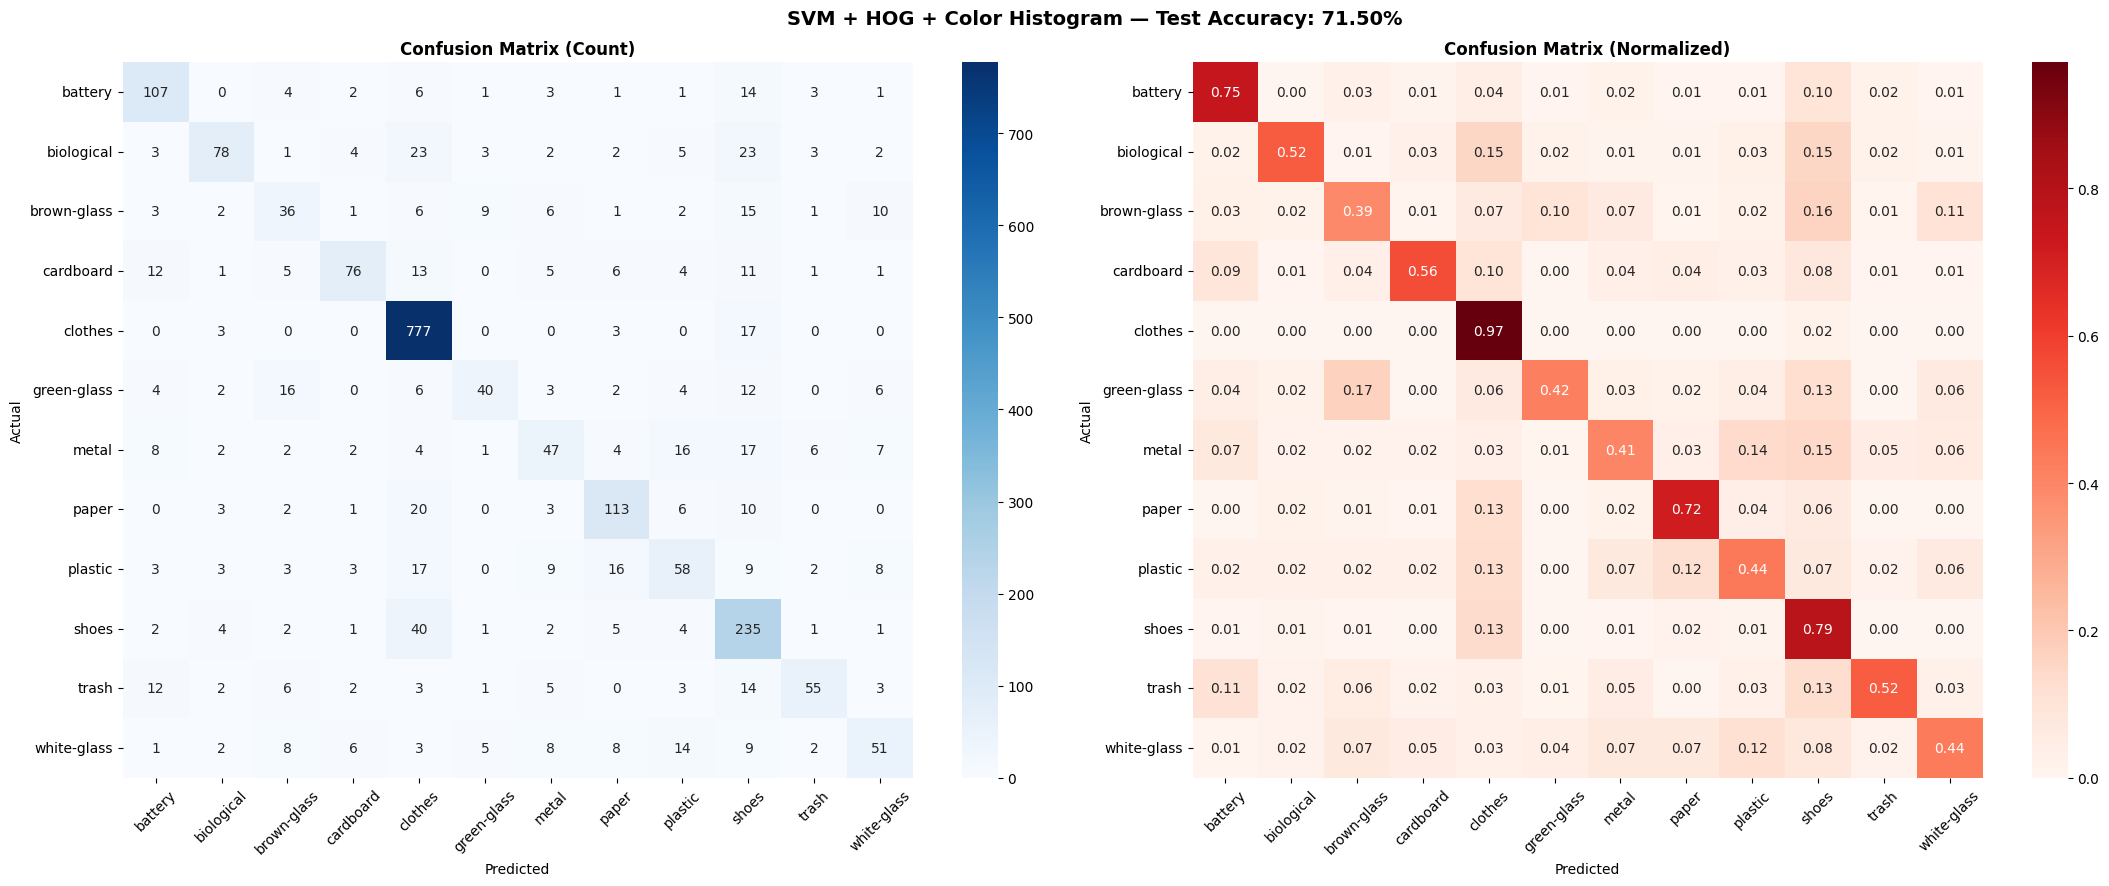

In [8]:
conf_matrix            = confusion_matrix(y_test, y_pred)
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

fig, (ax_count, ax_norm) = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax_count)
ax_count.set_title('Confusion Matrix (Count)', fontweight='bold')
ax_count.set_xlabel('Predicted')
ax_count.set_ylabel('Actual')
ax_count.tick_params(axis='x', rotation=45)

sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax_norm)
ax_norm.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax_norm.set_xlabel('Predicted')
ax_norm.set_ylabel('Actual')
ax_norm.tick_params(axis='x', rotation=45)

plt.suptitle(f'SVM + HOG + Color Histogram — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **INFERENCE**

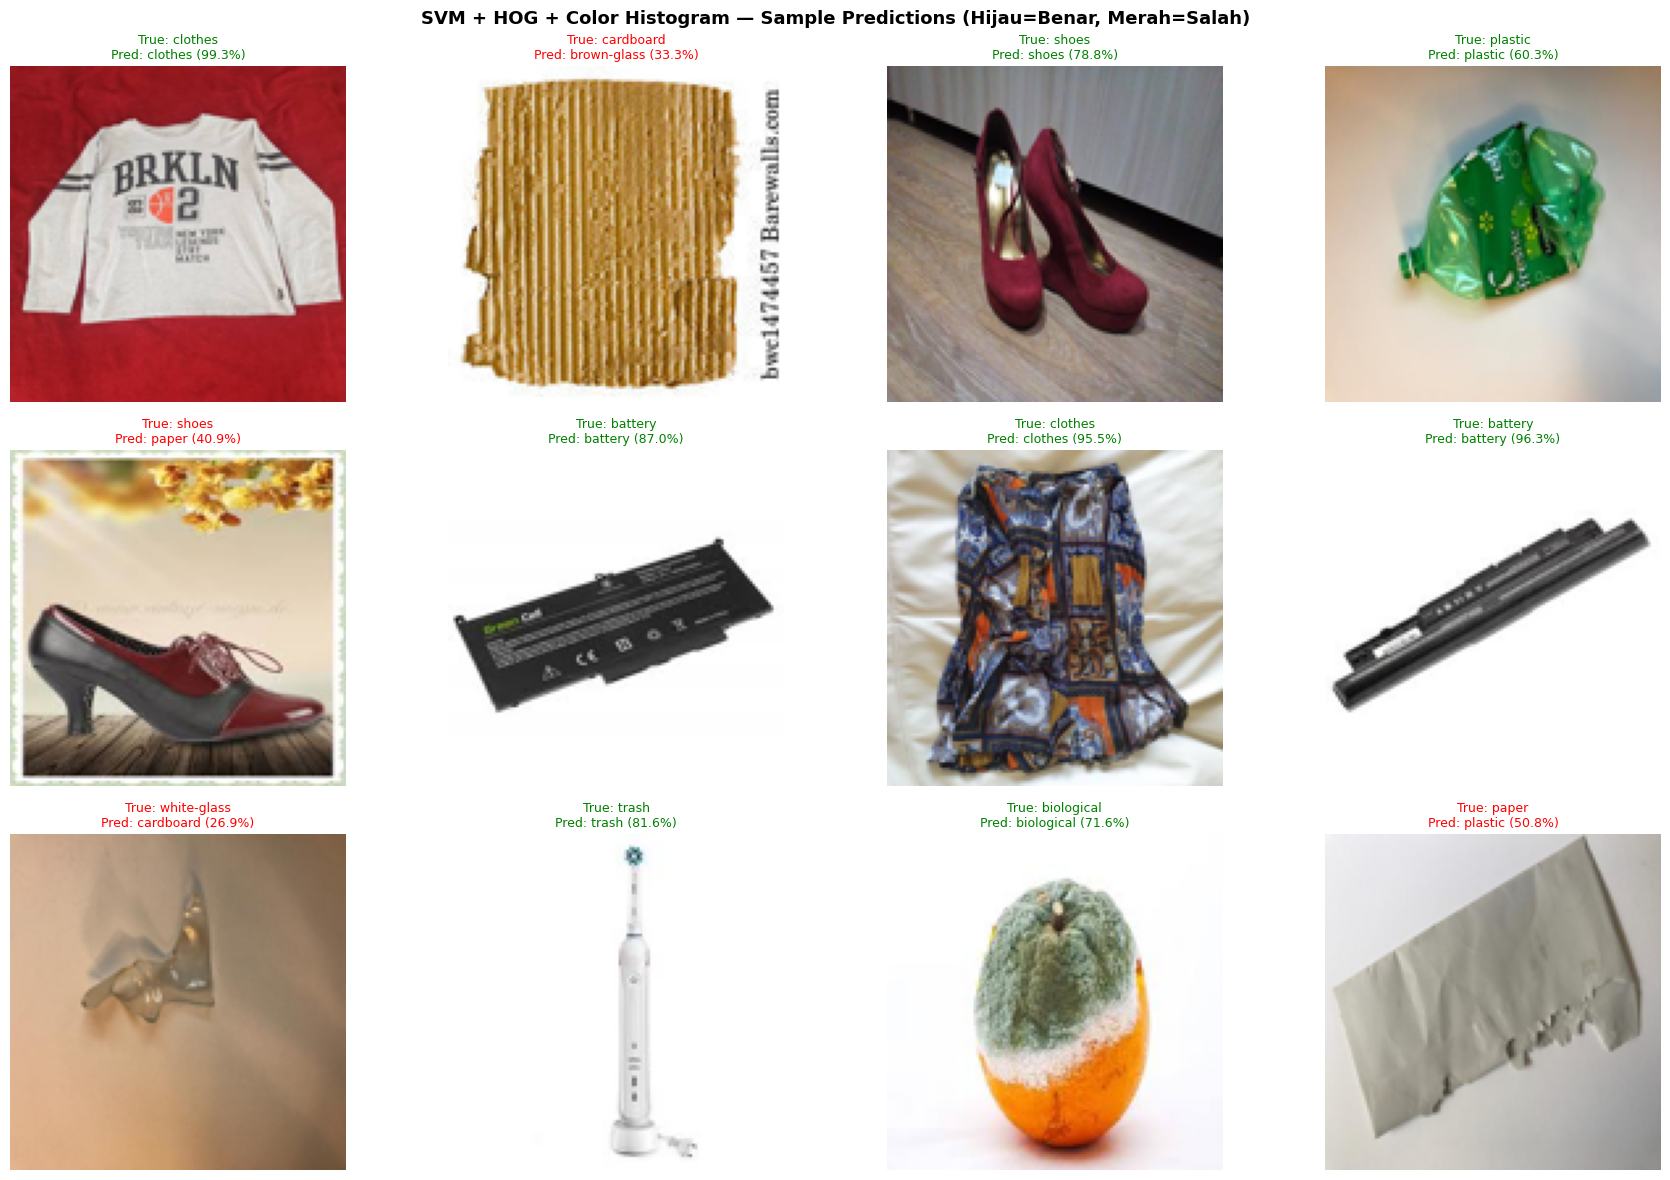

In [9]:
NUM_SAMPLE_PREDICTIONS = 12

all_test_images = []
for class_folder in sorted(TEST_DIR.iterdir()):
    if class_folder.is_dir():
        for img_path in class_folder.glob('*'):
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                all_test_images.append((img_path, class_folder.name))

random.shuffle(all_test_images)
sampled = all_test_images[:NUM_SAMPLE_PREDICTIONS]

sample_images_raw  = []
sample_true_labels = []
sample_features    = []

for img_path, class_name in sampled:
    img    = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    img_np = np.array(img, dtype=np.uint8)
    sample_images_raw.append(img_np)
    sample_true_labels.append(class_name)
    sample_features.append(extract_features_from_image(img_path))

sample_features = np.array(sample_features)
sample_preds    = pipeline.predict(sample_features)
sample_probs    = pipeline.predict_proba(sample_features)

cols = 4
rows = (NUM_SAMPLE_PREDICTIONS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i in range(NUM_SAMPLE_PREDICTIONS):
    true_label      = sample_true_labels[i]
    predicted_label = CLASS_NAMES[sample_preds[i]]
    confidence_pct  = np.max(sample_probs[i]) * 100
    is_correct      = true_label == predicted_label

    display_img = np.clip(sample_images_raw[i] / 255.0, 0, 1)
    axes[i].imshow(display_img)
    axes[i].set_title(
        f'True: {true_label}\nPred: {predicted_label} ({confidence_pct:.1f}%)',
        color='green' if is_correct else 'red',
        fontsize=9,
    )
    axes[i].axis('off')

for i in range(NUM_SAMPLE_PREDICTIONS, len(axes)):
    axes[i].axis('off')

plt.suptitle('SVM + HOG + Color Histogram — Sample Predictions (Hijau=Benar, Merah=Salah)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()